| Obs. | X1 | X2 |
|------|----|----|
|1|1|4|
|2|1|3|
|3|0|4|
|4|5|1|
|5|6|2|
|6|4|0|

### (a) 
### Plot the observations.

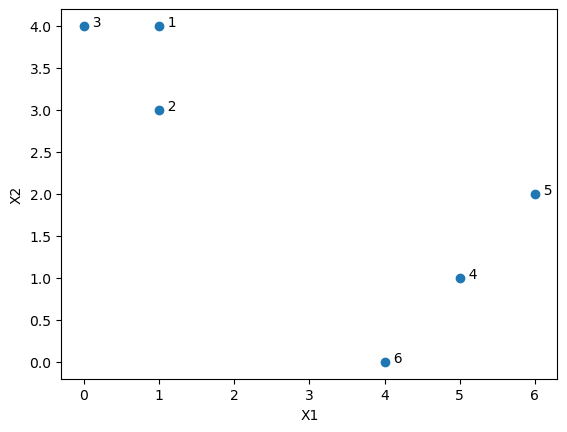

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

obs = np.array([
    [1, 4],
    [1, 3],
    [0, 4],
    [5, 1],
    [6, 2],
    [4, 0] 
])

plt.scatter(obs[:, 0], obs[:, 1],)
for i, (x, y) in enumerate(obs,1):
    plt.annotate(f'  {i}', (x, y))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

### (b)
### Randomly assign a cluster label to each observation. You can use the np.random.choice() function to do this. Report the cluster labels for each observation.n.n.

In [86]:
labels = np.random.choice([0, 1], size=len(obs))

for i, label in enumerate(labels):
    print(f'observation {i} is cluster {label}')

observation 0 is cluster 1
observation 1 is cluster 0
observation 2 is cluster 0
observation 3 is cluster 0
observation 4 is cluster 0
observation 5 is cluster 1


### (c)
### Compute the centroid for each cluster.

In [87]:
centroid0 = np.mean(obs[labels == 0], axis=0)
centroid1 = np.mean(obs[labels == 1], axis=0)

print(f"Cluster 0 centroid: ({centroid0[0]:.2f}, {centroid0[1]:.2f})")
print(f"Cluster 1 centroid: ({centroid1[0]:.2f}, {centroid1[1]:.2f})")

Cluster 0 centroid: (3.00, 2.50)
Cluster 1 centroid: (2.50, 2.00)


### (d)
### Assign each observation to the centroid to which it is closest, in terms of Euclidean distance. Report the cluster labels for each observation.

In [88]:
new_labels = []
for point in obs:
    dist0 = np.sqrt((point[0]-centroid0[0])**2 + (point[1]-centroid0[1])**2)
    dist1 = np.sqrt((point[0]-centroid1[0])**2 + (point[1]-centroid1[1])**2)
    new_labels.append(0 if dist0 < dist1 else 1)

for i, label in enumerate(new_labels):
    print(f'observation {i} is cluster {label}')

observation 0 is cluster 1
observation 1 is cluster 1
observation 2 is cluster 1
observation 3 is cluster 0
observation 4 is cluster 0
observation 5 is cluster 1


### (e)

In [89]:
while True:
    #c
    centroid0 = np.mean(obs[labels == 0], axis=0)
    centroid1 = np.mean(obs[labels == 1], axis=0)
    print(f"Cluster 0 centroid: ({centroid0[0]:.2f}, {centroid0[1]:.2f})")
    print(f"Cluster 1 centroid: ({centroid1[0]:.2f}, {centroid1[1]:.2f})")

    #d
    new_labels = []
    for point in obs:
        dist0 = np.sqrt((point[0]-centroid0[0])**2 + (point[1]-centroid0[1])**2)
        dist1 = np.sqrt((point[0]-centroid1[0])**2 + (point[1]-centroid1[1])**2)
        new_labels.append(0 if dist0 < dist1 else 1)
    
    new_labels = np.array(new_labels)

    if all(labels == new_labels):
        break
    labels = new_labels
new_labels

Cluster 0 centroid: (3.00, 2.50)
Cluster 1 centroid: (2.50, 2.00)
Cluster 0 centroid: (5.50, 1.50)
Cluster 1 centroid: (1.50, 2.75)
Cluster 0 centroid: (5.00, 1.00)
Cluster 1 centroid: (0.67, 3.67)


array([1, 1, 1, 0, 0, 0])

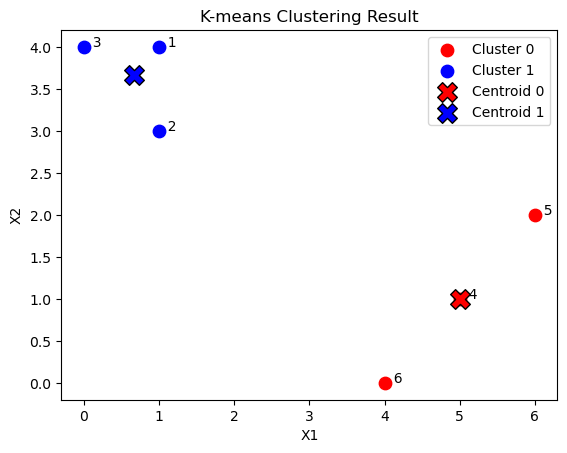

In [98]:
plt.figure()

plt.scatter(obs[labels==0, 0], obs[labels==0, 1], c='red', s=80, label='Cluster 0')
plt.scatter(obs[labels==1, 0], obs[labels==1, 1], c='blue', s=80, label='Cluster 1')
for i, (x, y) in enumerate(obs,1):
    plt.annotate(f'  {i}', (x, y))

plt.scatter(centroid0[0], centroid0[1], c='red', marker='X', s=200, label='Centroid 0', edgecolors='black')
plt.scatter(centroid1[0], centroid1[1], c='blue', marker='X', s=200, label='Centroid 1', edgecolors='black')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('K-means Clustering Result')
plt.legend()
plt.show()